# Linear regression from scratch

# Linear Regression using Gradient Descent

### 1. Prediction
The model predicts the output using the current weights and bias.

$$
\hat{y} = Xw + b
$$

where:

- $X$ = Input features
- $w$ = Weights
- $b$ = Bias
- $\hat{y}$ = Predicted values

---

### 2. Gradient of the Weights

The gradient tells us how much each weight should change.

$$
\frac{\partial J}{\partial w}
=
\frac{1}{n}
X^T(\hat{y}-y)
$$

---

### 3. Gradient of the Bias

The gradient tells us how much the bias should change.

$$
\frac{\partial J}{\partial b}
=
\frac{1}{n}
\sum_{i=1}^{n}(\hat{y}_i-y_i)
$$

---

### 4. Update the Weights

Move the weights in the opposite direction of the gradient.

$$
w = w - \alpha \frac{\partial J}{\partial w}
$$

---

### 5. Update the Bias

$$
b = b - \alpha \frac{\partial J}{\partial b}
$$

where:

- $\alpha$ = Learning rate
- $n$ = Number of training samples
- $y$ = Actual values
- $\hat{y}$ = Predicted values

Mean squared error: 352.61423842730574 


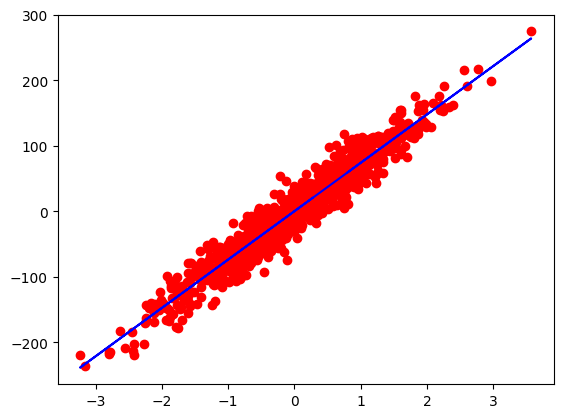

In [39]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
# Create dataset
x,y=datasets.make_regression(n_samples=1000,n_features=1,noise=20,random_state=123)

# split into test and train 
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=123)

# Class for regression
class LinearRegression():
    def __init__(self,lr=0.0001,iteration=100000):
        self.lr=lr
        self.iteration=iteration
        
    def fit(self,x,y):
        sample,feature=x.shape
        self.weight=np.zeros(feature)
        self.bias=0
        for _ in range(self.iteration):
            prediction=np.dot(x,self.weight)+self.bias
            weight_gradient= (np.dot(x.T,(prediction-y)))/sample
            bias_gradient=((prediction-y).sum())/sample
            self.weight-=self.lr*weight_gradient
            self.bias-=self.lr*bias_gradient
            
    def predict(self,x):
        return (np.dot(x,self.weight)+self.bias)


# define Cost function - Mean squared error
def Mean_Squared_Error(prediction,y):
   return ((((prediction-y)**2).sum())/y.shape[0])

# make prediction 
reg=LinearRegression()
reg.fit(x_train,y_train)
prediction=reg.predict(x_test)

# Find the error
print(f"Mean squared error: {Mean_Squared_Error(prediction,y_test)} ")

# Plot the graph
plt.plot(x,reg.predict(x),c='b')
plt.scatter(x,y,c='r',marker='o')